In [1]:
import importlib
import hmm_functions # import entire module so we can call importlib.reload() on it
importlib.reload(hmm_functions)
from hmm_functions import load_data, create_folds, print_n_param_updates_per_epoch, get_hyperparam_combinations, run_grid_search, plot_cv_loss, hyperparam_performance, run_full_model_eval
import numpy as np
import nibabel as nib
import pandas as pd
import os
import pickle

import matplotlib.pyplot as plt
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes
from osl_dynamics.analysis import post_hoc

# Prepare Data

In [2]:
experiment = 'CIMT/LLstim'
data_path = '../CIMT_data/no_wm/LLstim/stim_phase_coherence_matrices_no_wm_114roi.npy'
data_prep_method = 'LEiDA' # 'ICA' or 'LEiDA'

In [3]:
# Create data array X
X, full_data = load_data(
    data_path=data_path, 
    data_prep_method=data_prep_method, 
    standardize=False, # False for LEiDA
)

# Create subj_order and y
if data_prep_method == 'ICA':   
    with open(os.path.join(data_path, data_path.split('/')[-1] + 'SelectedDataFolders.txt'), 'r') as f:
        subj_order = f.readlines()

    y = []
    i = 0
    for tc in sorted(os.listdir(data_path)):
        if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
            subj_order[i] = subj_order[i][-17:-1]
            y.append(subj_order[i][:-4])
            i += 1

    # Create ICA .nii file excluding bad_ICs
    denoised_gica_path = os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_denoised_.nii')
    if not os.path.exists(denoised_gica_path):
        gica = nib.load(os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_.nii'))
        gica_data = gica.get_fdata()
        print("Before:", gica_data.shape)
        gica_data = np.delete(gica_data, obj=[IC - 1 for IC in bad_ICs], axis=3)
        print("After:", gica_data.shape)
        gica_nii = nib.Nifti1Image(gica_data, gica.affine, header=gica.header)
        nib.save(gica_nii, denoised_gica_path)
elif data_prep_method == 'LEiDA':
    metadata_corrected = pd.read_csv('../CIMT_data/no_wm/LLstim/LLstim_info/metadata_corrected.csv')
    subj_order = metadata_corrected['subject_id'].unique()
    y = [subj[:-4] for subj in subj_order]
else:
    raise ValueError("invalid data_prep_method. Only ICA and LEiDA are supported")

subj_order = np.array(subj_order) # the subject labels in the EXACT order that the subjects appear in X
y = np.array(y) # the experimental cohort of each subject in the EXACT order that the subjects appear in X
print("X shape:", X.shape)
print("full_data attributes:", full_data)
print("subj_order shape:", subj_order.shape)
print("y shape:", y.shape)

Loading files:   0%|          | 0/114 [00:00<?, ?it/s]

X shape: (114, 250, 114)
full_data attributes: Data
 id: 13339957520
 n_sessions: 114
 n_samples: 28500
 n_channels: 114
subj_order shape: (114,)
y shape: (114,)


In [4]:
print(subj_order)
print(np.unique(y))

['CCI_CIMT_07d_001' 'CCI_CIMT_07d_004' 'CCI_CIMT_07d_006'
 'CCI_CIMT_07d_007' 'CCI_CIMT_07d_010' 'CCI_CIMT_07d_011'
 'CCI_CIMT_07d_020' 'CCI_CIMT_07d_022' 'CCI_CIMT_07d_024'
 'CCI_CIMT_07d_032' 'CCI_CIMT_07d_033' 'CCI_CIMT_07d_037'
 'CCI_CIMT_07d_038' 'CCI_CIMT_07d_039' 'CCI_CIMT_07d_040'
 'CCI_CIMT_21d_001' 'CCI_CIMT_21d_004' 'CCI_CIMT_21d_006'
 'CCI_CIMT_21d_007' 'CCI_CIMT_21d_010' 'CCI_CIMT_21d_011'
 'CCI_CIMT_21d_020' 'CCI_CIMT_21d_022' 'CCI_CIMT_21d_024'
 'CCI_CIMT_21d_032' 'CCI_CIMT_21d_033' 'CCI_CIMT_21d_037'
 'CCI_CIMT_21d_038' 'CCI_CIMT_21d_039' 'CCI_CIMT_21d_040'
 'CCI_CIMT_49d_001' 'CCI_CIMT_49d_004' 'CCI_CIMT_49d_006'
 'CCI_CIMT_49d_007' 'CCI_CIMT_49d_010' 'CCI_CIMT_49d_011'
 'CCI_CIMT_49d_020' 'CCI_CIMT_49d_022' 'CCI_CIMT_49d_024'
 'CCI_CIMT_49d_032' 'CCI_CIMT_49d_033' 'CCI_CIMT_49d_037'
 'CCI_CIMT_49d_038' 'CCI_CIMT_49d_039' 'CCI_CIMT_49d_040'
 'CCI_none_07d_002' 'CCI_none_07d_003' 'CCI_none_07d_005'
 'CCI_none_07d_009' 'CCI_none_07d_012' 'CCI_none_07d_013'
 'CCI_none_07d

In [5]:
n_splits = 5
split_plan = create_folds(
    n_splits=n_splits, 
    X=X, 
    y=y, 
    inner_val_size=0.2, 
    random_state=42,
    standardize=False, # False for LEiDA
)

Fold 1:
  Train: index=[  3   4   5   6   7   8   9  10  11  12  13  14  18  19  20  21  22  23
  24  25  26  27  28  29  33  34  35  36  37  38  39  40  41  42  43  44
  48  49  50  51  52  53  54  55  56  57  58  59  63  64  65  66  67  68
  69  70  71  72  73  74  78  79  80  81  82  83  84  85  86  87  88  89
  92  93  94  95  96  97 100 101 102 103 104 105 107 108 109 110 111 112
 113]
  Test:  index=[  0   1   2  15  16  17  30  31  32  45  46  47  60  61  62  75  76  77
  90  91  98  99 106]


Loading files:   0%|          | 0/91 [00:00<?, ?it/s]

Loading files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Fold 5:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  15  16  17  18  19  20
  21  22  23  24  25  26  30  31  32  33  34  35  36  37  38  39  40  41
  45  46  47  48  49  50  51  52  53  54  55  56  60  61  62  63  64  65
  66  67  68  69  70  71  75  76  77  78  79  80  81  82  83  84  85  86
  90  91  92  93  94  95  96  98  99 100 101 102 103 106 107 108 109 110
 111 112]
  Test:  index=[ 12  13  14  27  28  29  42  43  44  57  58  59  72  73  74  87  88  89
  97 104 105 113]


Loading files:   0%|          | 0/92 [00:00<?, ?it/s]

Loading files:   0%|          | 0/22 [00:00<?, ?it/s]

Loading files:   0%|          | 0/73 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

# Train HMM

In [6]:
if data_prep_method == 'ICA':
    hmm_run = f"ICA_{full_data.n_channels}c_no_TDE"
elif data_prep_method == 'LEiDA':
    hmm_run = f"LEiDA_{full_data.n_channels}c_no_TDE"

In [7]:
hyperparam_grid = {
    'k': [5], # range(2, 15),
    'sequence_length': [50],
    'learn_means': [True], # try True for LEiDA
    'learn_covariances': [True],
    'set_regularizers': [True],
    'batch_size': [32], 
    'learning_rate': [1e-4, 3e-4, 1e-3], 
    'lr_decay': [0.0, 0.005, 0.01], # Optimize learning_rate with a lr_decay of 0.05 first, then optimize lr_decay with the commented values
    'n_epochs': [10000], # using early stopping anyways, so just set to a high number
    'patience': [20],
}

print_n_param_updates_per_epoch(hyperparam_grid, full_data)
        
print(hmm_run)

Number of parameter updates per epoch with sequence_length=50 and batch_size=32: 18
LEiDA_114c_no_TDE


In [76]:
model_eval_log = {}
model_eval_log_save_path = f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl'

In [77]:
if os.path.exists(f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl'):
    with open(f'{experiment}/grid_search/model_eval_log_{hmm_run}.pkl', 'rb') as f:
        model_eval_log = pickle.load(f)
else:
    os.makedirs('grid_search', exist_ok=True)

sorted(model_eval_log.keys())

[5, 6, 7, 8]

In [10]:
run_grid_search(
    model_eval_log=model_eval_log, 
    model_eval_log_save_path=model_eval_log_save_path, 
    hyperparam_grid=hyperparam_grid, 
    seed=42, 
    split_plan=split_plan,
)


Hyperparam set 1: {'k': 5, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}

Fold 1...


2026-04-28 16:24:17 INFO osl-dynamics [hmm.py:368:set_regularizers]: Setting regularizers
2026-04-28 16:24:17.933050: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-28 16:24:17 INFO osl-dynamics [inf_mod_base.py:1435:random_state_time_course_initialization]: Random state time course initialization
2026-04-28 16:24:18 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 0
2026-04-28 16:24:18 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-28 16:24:18 INFO osl-dynamics [inf_mod_base.py:1341:random_subset_initialization]: Random subset initialization
2026-04-28 16:24:18 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 0


random_state_time_course_initialization can't simulate a state time course where each state activates. Switching to using random_subset_initialization instead.


2026-04-28 16:24:20 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 1
2026-04-28 16:24:23 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 2
2026-04-28 16:24:25 INFO osl-dynamics [inf_mod_base.py:1385:random_subset_initialization]: Using initialization 0


Getting free energy:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-04-29 03:31:13 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 0
2026-04-29 03:31:13 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-29 03:31:15 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 1
2026-04-29 03:31:15 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-29 03:31:16 INFO osl-dynamics [inf_mod_base.py:1341:random_subset_initialization]: Random subset initialization
2026-04-29 03:31:16 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 0


random_state_time_course_initialization can't simulate a state time course where each state activates. Switching to using random_subset_initialization instead.


2026-04-29 03:31:18 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 1
2026-04-29 03:31:20 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 2
2026-04-29 03:31:32 INFO osl-dynamics [inf_mod_base.py:1385:random_subset_initialization]: Using initialization 0


Getting free energy:   0%|          | 0/4 [00:00<?, ?it/s]

Time elapsed for this fold: 108.356 seconds


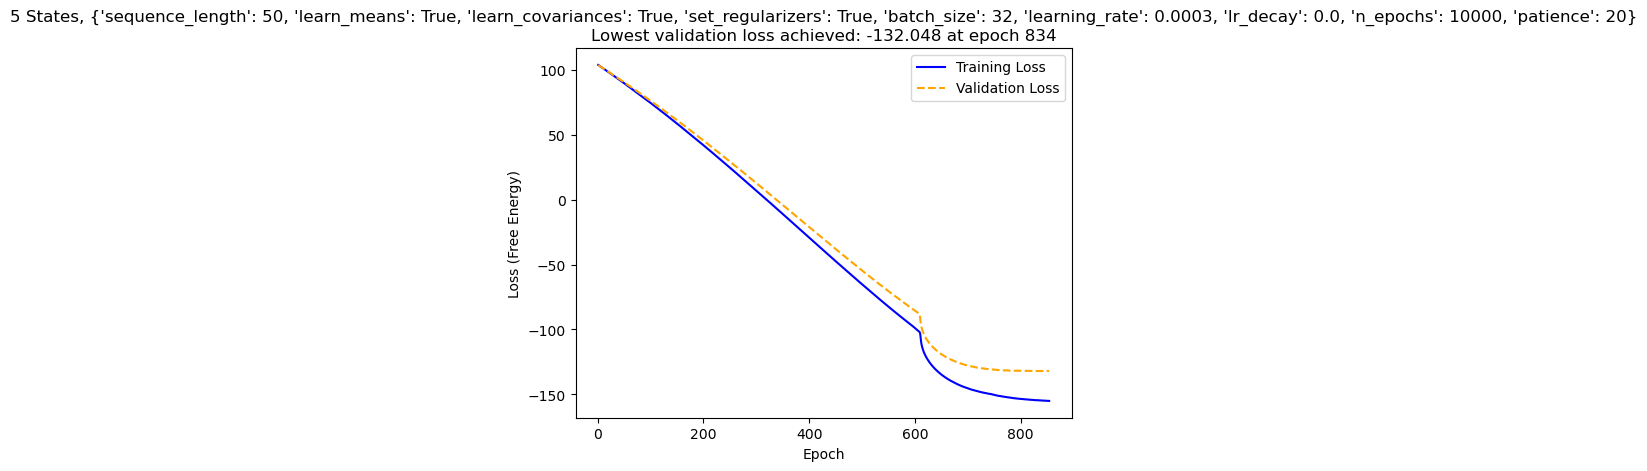

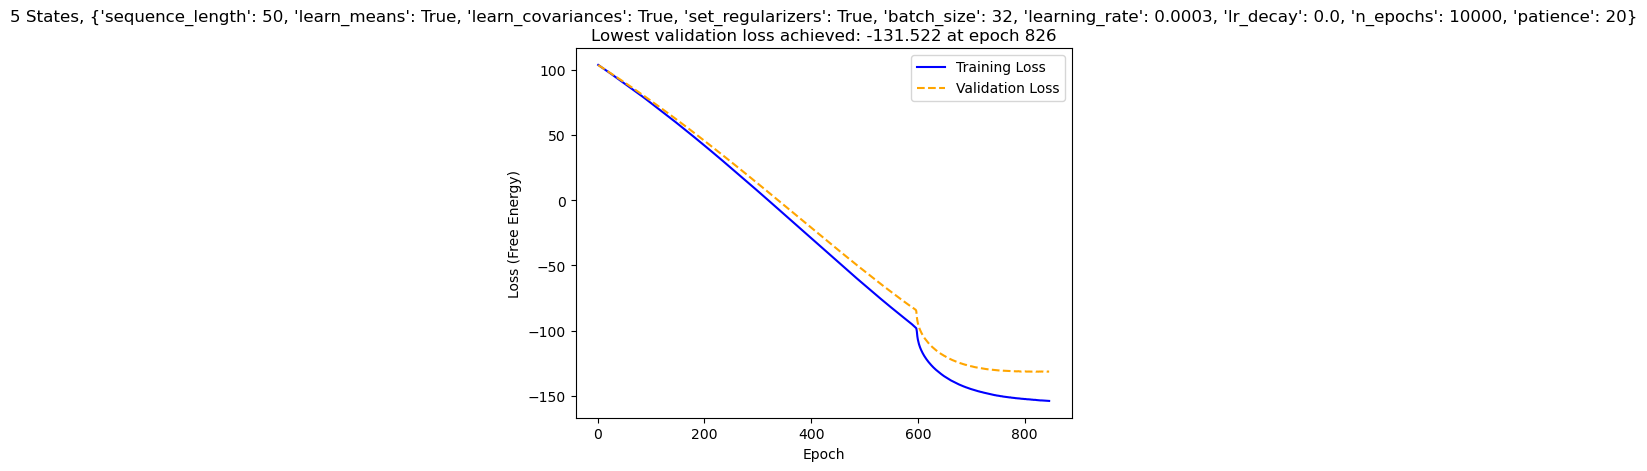

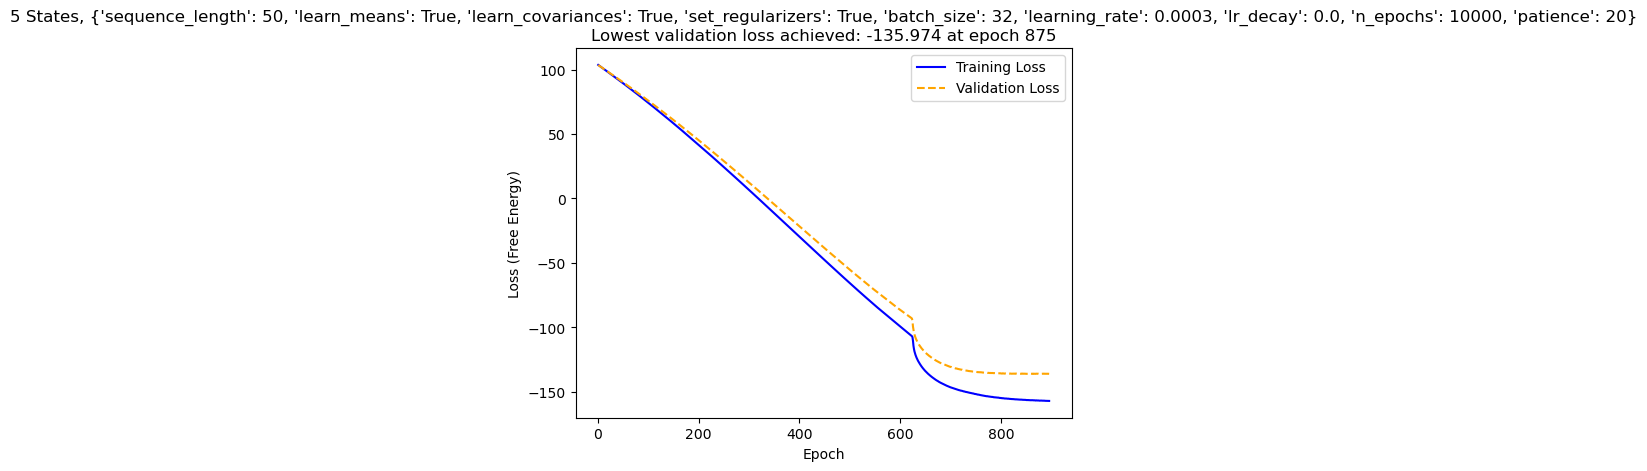

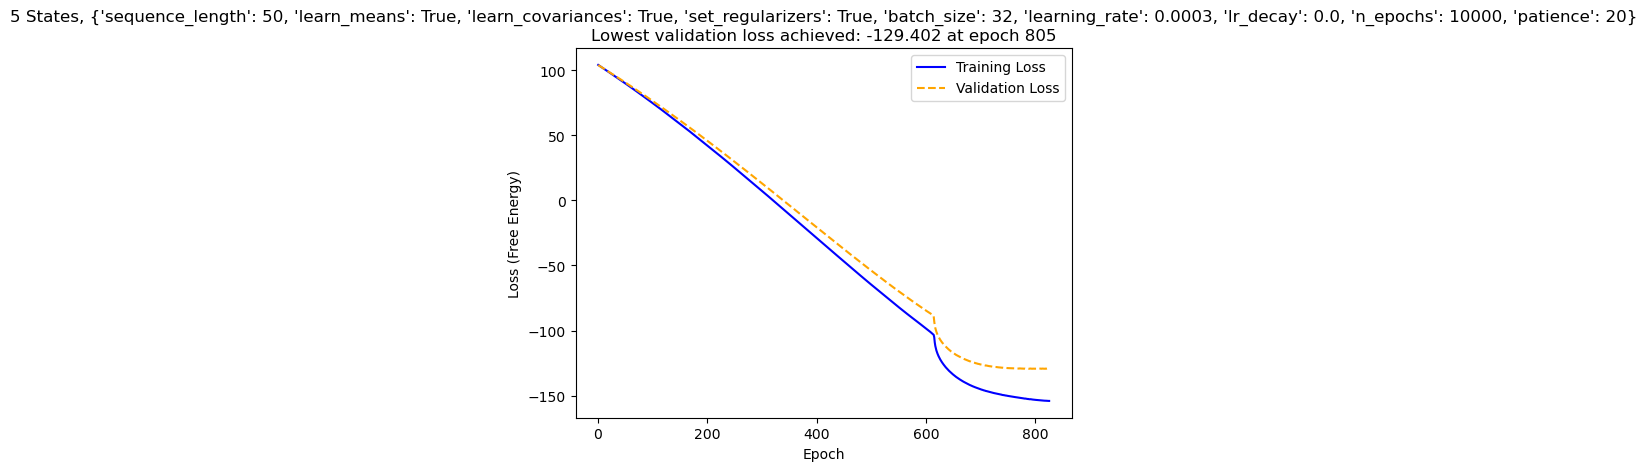

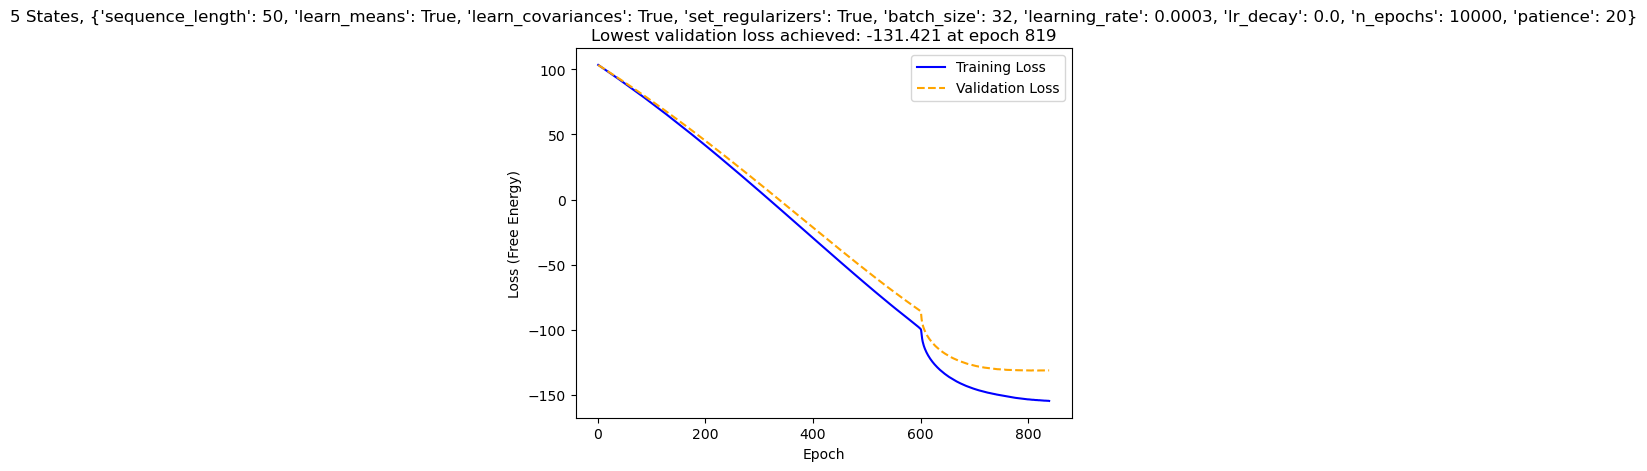

In [11]:
plot_cv_loss(model_eval_log, 5, split_plan)

In [12]:
hyperparam_performance(model_eval_log, 5)

{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}: -132.747, took 831.8 epochs on average
{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}: -132.651, took 2674.2 epochs on average
{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}: -132.322, took 241.2 epochs on average
{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.005, 'n_epochs': 10000, 'patience': 20}: -116.230, took 1989.6 epochs on average
{'sequence_length': 50, 'learn_means': True, 'learn_covariances': 

# Compute Model Evaluation Metrics on Full Dataset 

In [13]:
results_path = f'{experiment}/results/{hmm_run}'

In [14]:
run_full_model_eval(
    model_eval_log=model_eval_log, 
    model_eval_log_save_path=model_eval_log_save_path, 
    k_values=[5], 
    n_realizations=10, 
    model_save_metric='total_LL', 
    seed=42, 
    full_data=full_data,
    results_path=results_path, 
)

2026-04-29 03:33:02 INFO osl-dynamics [hmm.py:368:set_regularizers]: Setting regularizers


Fitting model with 5 states...
Realization 1:


2026-04-29 03:33:02 INFO osl-dynamics [inf_mod_base.py:1435:random_state_time_course_initialization]: Random state time course initialization
2026-04-29 03:33:02 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 0
2026-04-29 03:33:02 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-29 03:33:05 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 1
2026-04-29 03:33:05 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-29 03:33:08 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 2
2026-04-29 03:33:08 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-29 03:33:11 INFO osl-dynamics [inf_mod_base.py:1477:random_state

Getting free energy:   0%|          | 0/18 [00:00<?, ?it/s]

2026-04-29 03:45:08 INFO osl-dynamics [hmm.py:368:set_regularizers]: Setting regularizers


...

2026-04-29 05:21:12 INFO osl-dynamics [hmm.py:368:set_regularizers]: Setting regularizers


Time elapsed for this realization: 725.079 seconds
Realization 10:


2026-04-29 05:21:12 INFO osl-dynamics [inf_mod_base.py:1435:random_state_time_course_initialization]: Random state time course initialization
2026-04-29 05:21:12 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 0
2026-04-29 05:21:12 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-29 05:21:15 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 1
2026-04-29 05:21:15 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-29 05:21:18 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 2
2026-04-29 05:21:18 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-04-29 05:21:21 INFO osl-dynamics [inf_mod_base.py:1477:random_state

Getting free energy:   0%|          | 0/18 [00:00<?, ?it/s]

Time elapsed for this realization: 719.468 seconds
Saving model with highest total log-likelihood ...


# Compute Summary Statistics

In [98]:
optimal_num_states = 7
model = load(model_eval_log[optimal_num_states]['best_realization_path'])

2026-04-29 14:09:35 INFO osl-dynamics [mod_base.py:781:load]: Loading model: CIMT/LLstim/results/LEiDA_114c_no_TDE/7_states/7_states_model


In [99]:
inf_params_path = f'{results_path}/{optimal_num_states}_states/inf_params'
os.makedirs(inf_params_path, exist_ok=True)

In [100]:
alpha_path = f'{inf_params_path}/alp_{optimal_num_states}_states.pkl'
if os.path.exists(alpha_path):
    alpha = pickle.load(open(alpha_path, 'rb'))
else:
    alpha = model.get_alpha(full_data)
    pickle.dump(alpha, open(alpha_path, 'wb'))

Getting alpha:   0%|          | 0/114 [00:00<?, ?it/s]

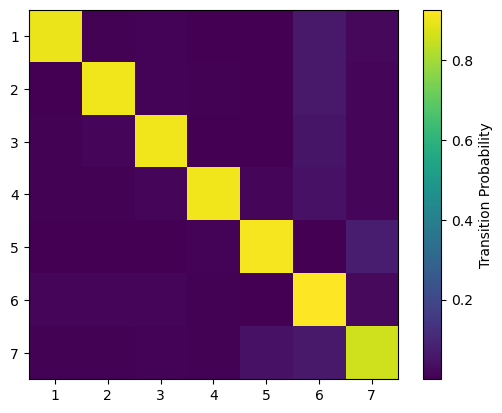

In [81]:
trans_matrix = model.get_trans_prob()
plt.imshow(trans_matrix, origin='upper')
plt.xticks(ticks=range(0, optimal_num_states), labels=range(1, optimal_num_states + 1))
plt.yticks(ticks=range(0, optimal_num_states), labels=range(1, optimal_num_states + 1))
plt.colorbar(label='Transition Probability')
plt.show()

In [82]:
# Now the group-level means and covs
means, covs = model.get_means_covariances()
means.shape, covs.shape

((7, 114), (7, 114, 114))

In [83]:
np.save(f"{inf_params_path}/means_{optimal_num_states}_states.npy", means)
np.save(f"{inf_params_path}/covs_{optimal_num_states}_states.npy", covs)

In [84]:
type(alpha), len(alpha) # each element of alpha is a subject

(list, 114)

In [85]:
# Hard classify the state probabilities (i.e., for each time point set each probability to either 0 or 1)
stc = modes.argmax_time_courses(alpha) # state time course
print(type(stc))
print(len(stc))
print(stc[0].shape)

<class 'list'>
114
(250, 7)


In [86]:
# Fractional occupancy (FO)
fo = modes.fractional_occupancies(stc)
fo.shape

(114, 7)

In [87]:
# FO of each state averaged across subjects
sorted_fos = [] # (state_num, FO)
mean_fos = np.mean(fo, axis=0)
for i in range(optimal_num_states):
    sorted_fos.append((i + 1, mean_fos[i]))

sorted_fos.sort(key=lambda x: x[1], reverse=True)
for state, f in sorted_fos:
    print(f"State {state} FO:", f)

State 6 FO: 0.39810526315789485
State 7 FO: 0.1558596491228069
State 3 FO: 0.12094736842105257
State 5 FO: 0.1032982456140351
State 2 FO: 0.09084210526315785
State 1 FO: 0.06680701754385959
State 4 FO: 0.06414035087719294


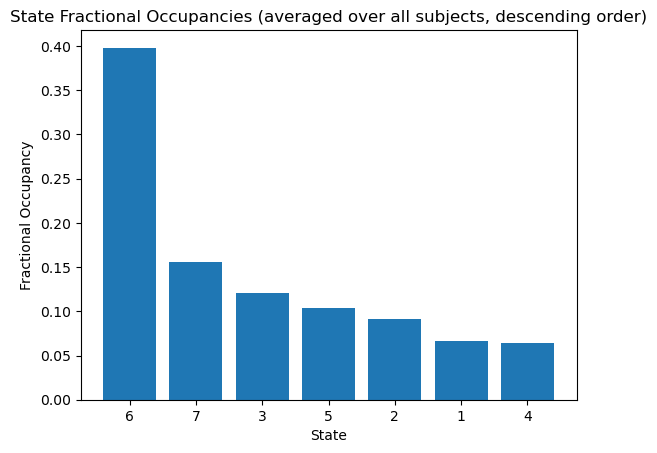

In [88]:
plt.bar(x=[str(x[0]) for x in sorted_fos], height=[x[1] for x in sorted_fos])
plt.title("State Fractional Occupancies (averaged over all subjects, descending order)")
plt.xlabel("State")
plt.ylabel("Fractional Occupancy")
plt.show()

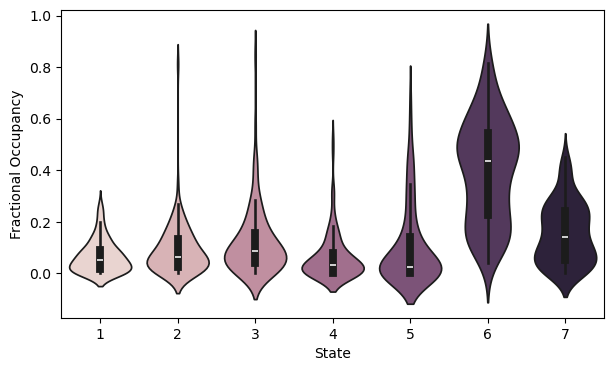

In [89]:
# Plot the distribution of fractional occupancy (FO) across subjects
fig, ax = plotting.plot_violin(fo.T, x_label="State", y_label="Fractional Occupancy")

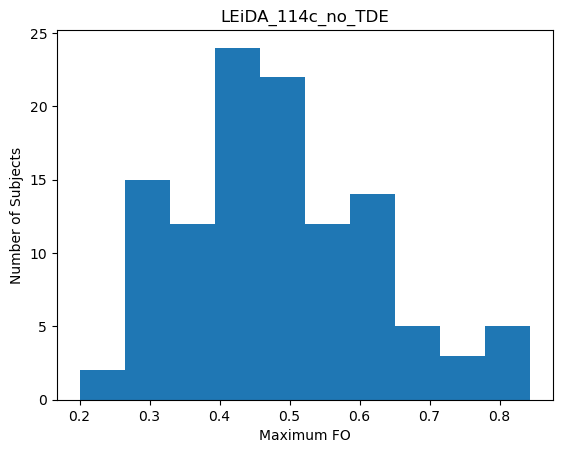

In [90]:
# Plot historgram of maximum FOs (maxFOs) to make sure there aren't states dominating subject time courses
fig, ax = plt.subplots(1, 1)
ax.hist(np.max(fo, axis=1))
ax.set_title(hmm_run)
ax.set_xlabel("Maximum FO")
ax.set_ylabel("Number of Subjects")

plt.show()

In [91]:
# Mean maxFOs for each experimental group
for group in np.unique(y):
    print(f"{group}:", np.mean(np.max(fo[np.where(y == group)[0],], axis=1)))

CCI_CIMT_07d: 0.45306666666666673
CCI_CIMT_21d: 0.4784
CCI_CIMT_49d: 0.49439999999999995
CCI_none_07d: 0.43200000000000005
CCI_none_21d: 0.5754666666666668
CCI_none_49d: 0.4776
SHM_none_07d: 0.45349999999999996
SHM_none_21d: 0.547
SHM_none_49d: 0.4455


In [92]:
count = 0
for subj_idx in np.where(np.max(fo, axis=1) >= 0.9)[0]:
    count += 1
    print(subj_order[subj_idx][-17:])

count

0

## Subject-Level State Time Courses (Viterbi Paths)

In [93]:
stim_times = ([0] * 15 + [1] * 10) * 10
len(stim_times)

250

In [94]:
def add_stim_times(ax):
    for i in range(len(stim_times)):
        if stim_times[i]:
            ax.plot(i, 0, color='black', marker='o')

### 07d

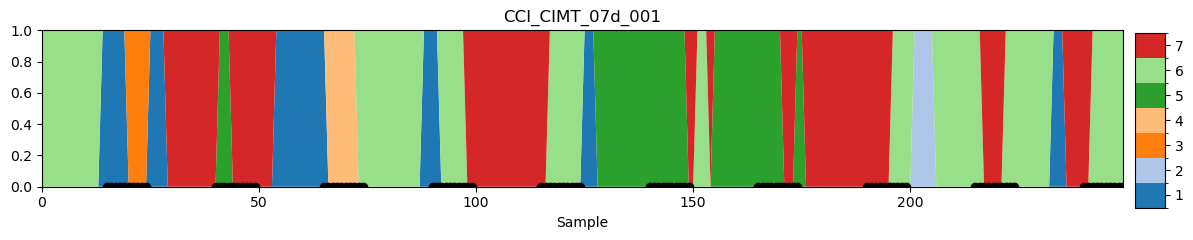

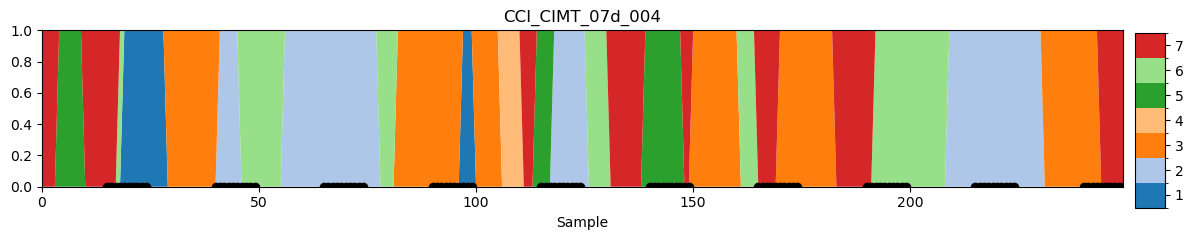

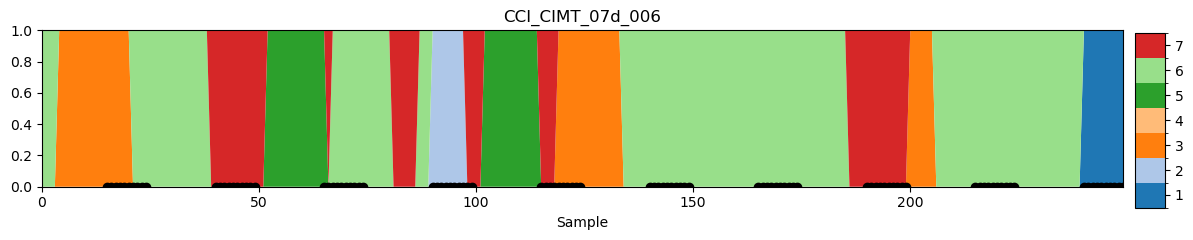

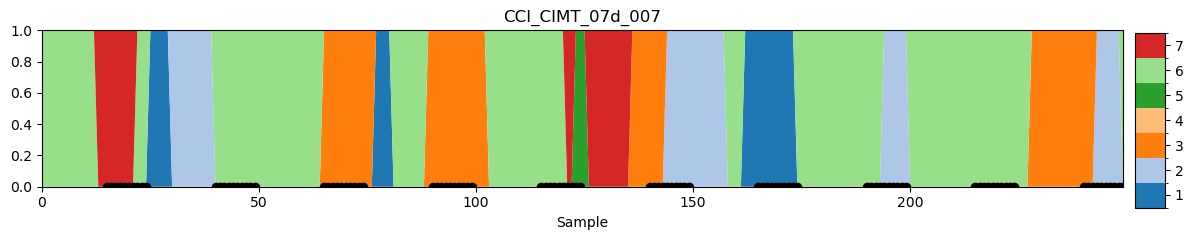

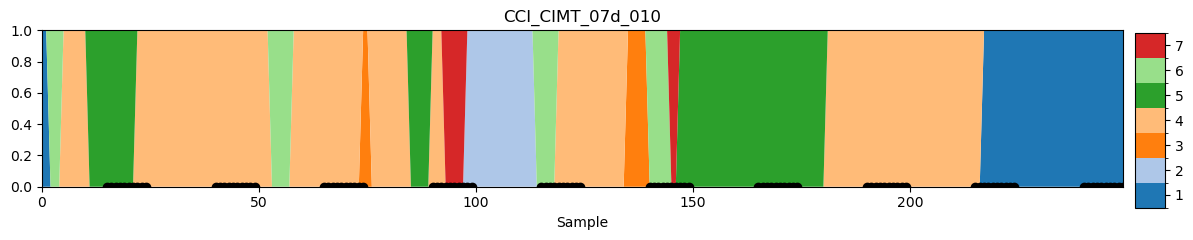

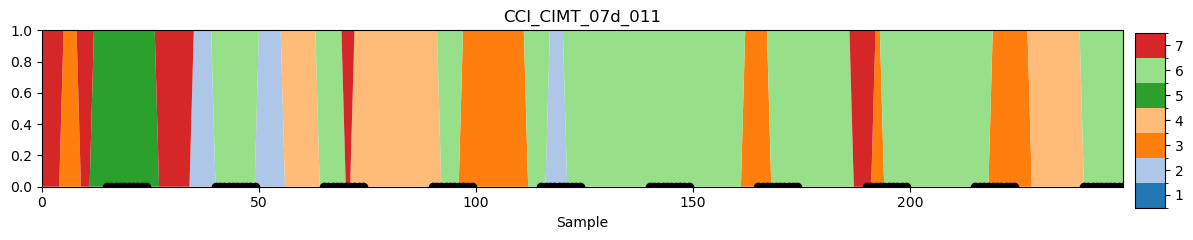

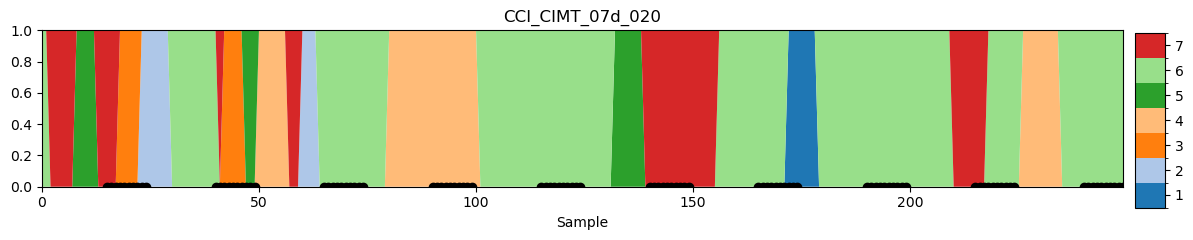

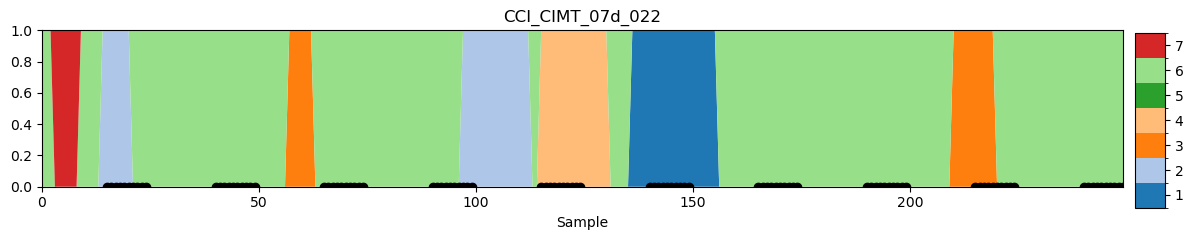

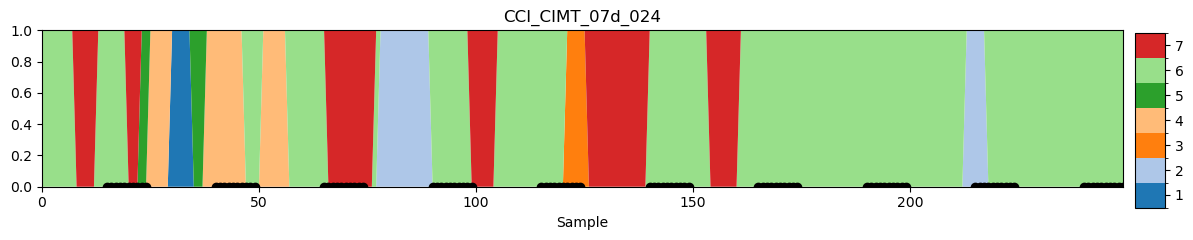

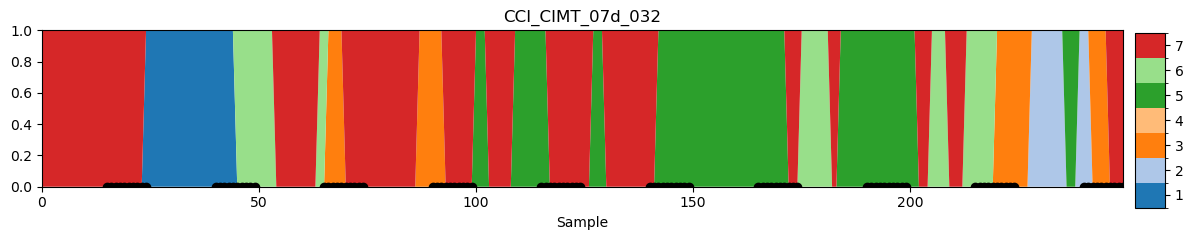

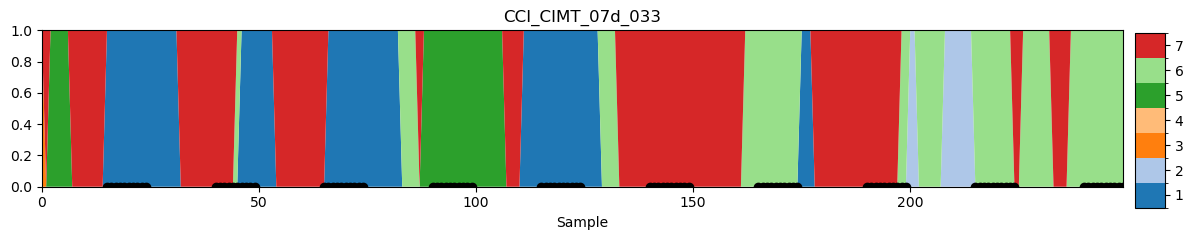

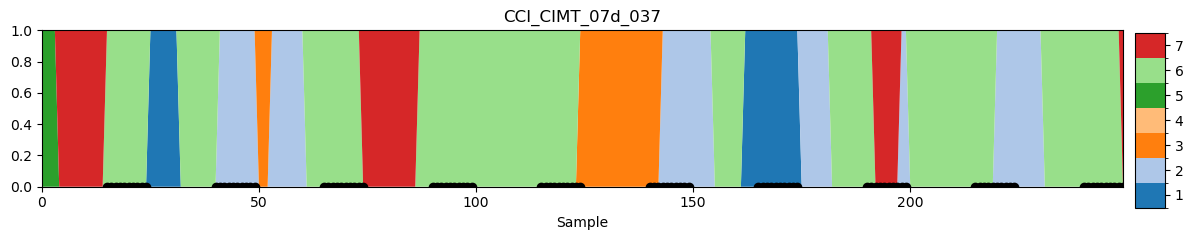

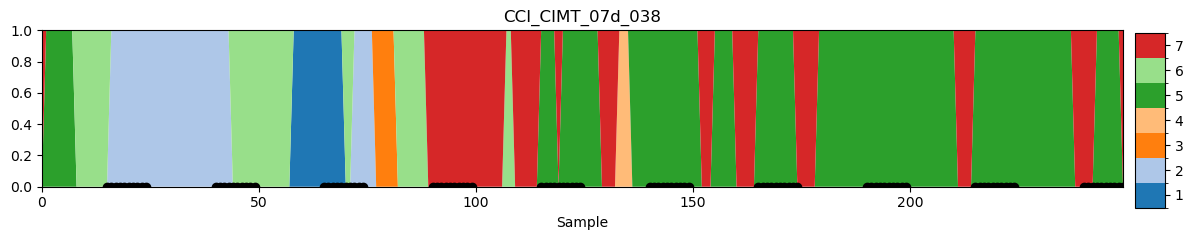

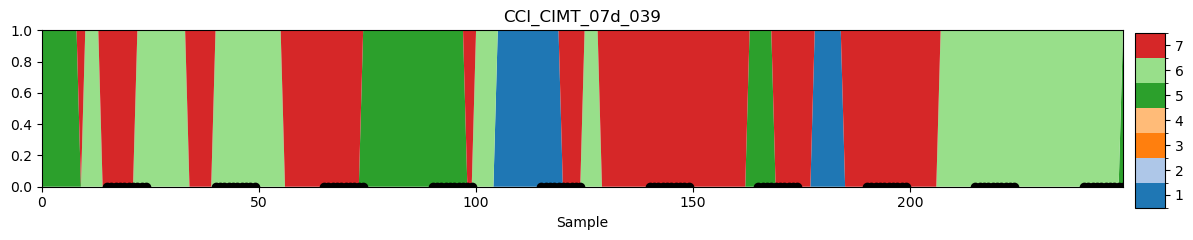

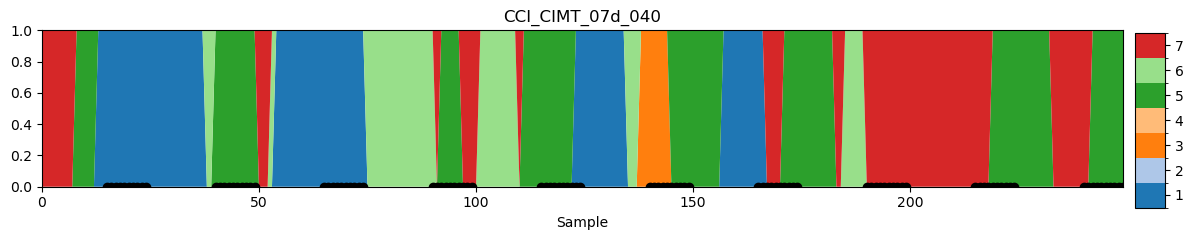

In [95]:
# CCI_CIMT_07d
for subj in np.where(y == 'CCI_CIMT_07d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'CIMT/LLstim' or experiment == 'CIMT/RLstim':
        add_stim_times(ax[0])

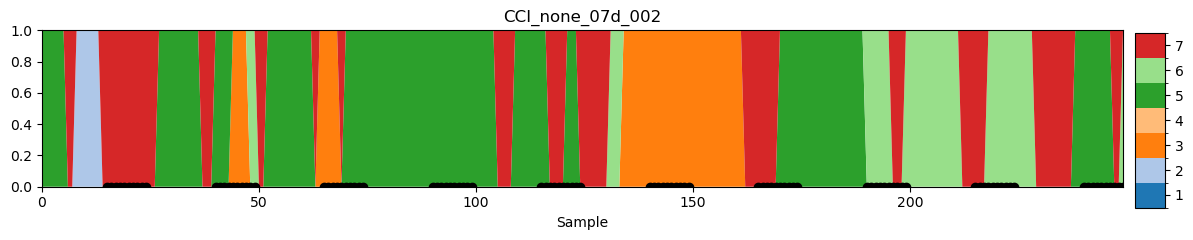

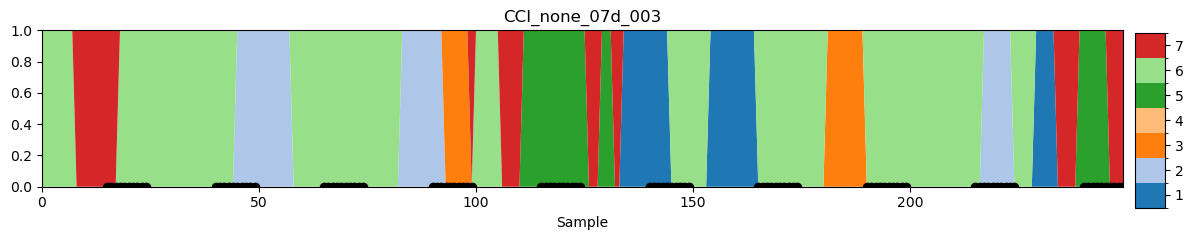

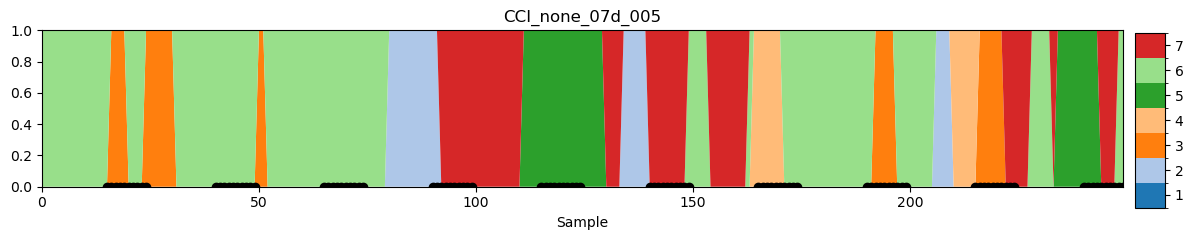

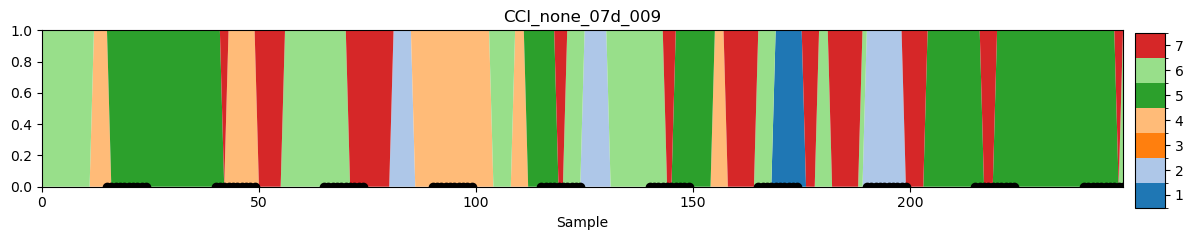

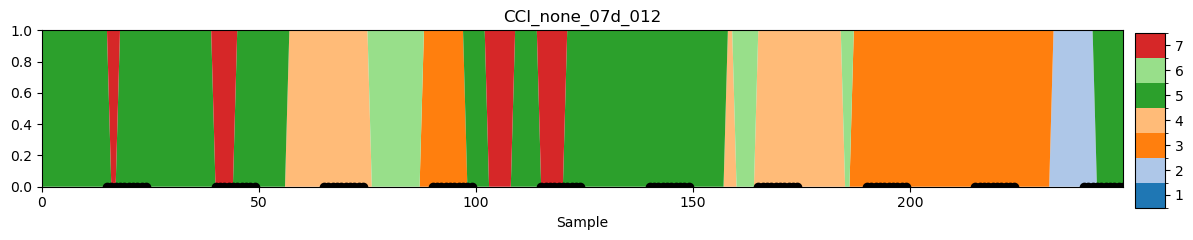

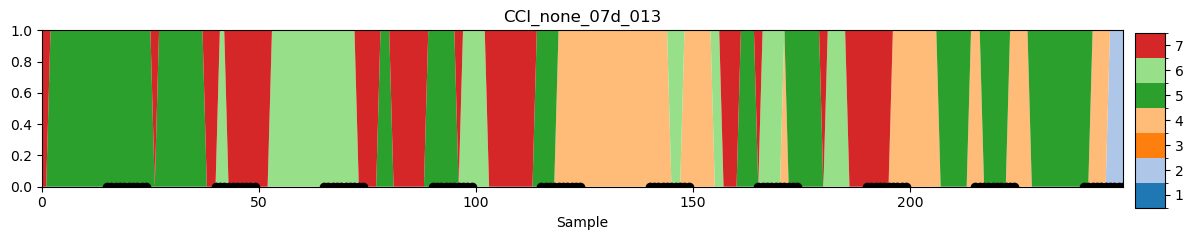

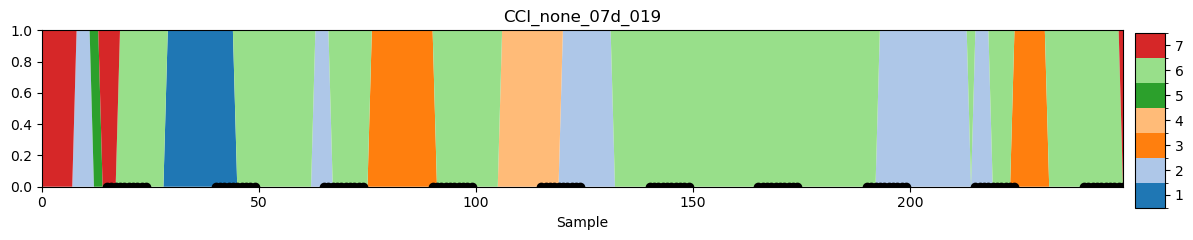

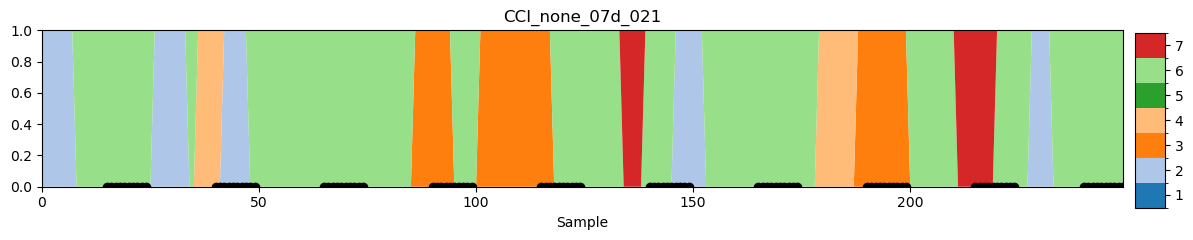

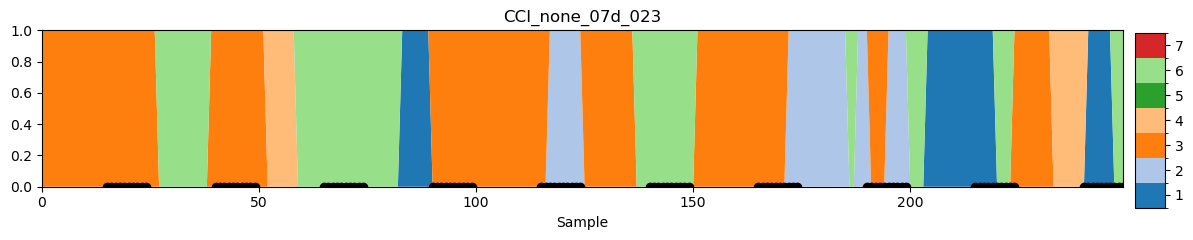

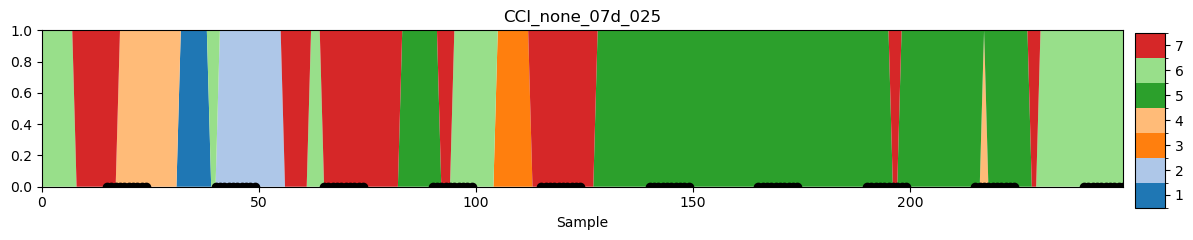

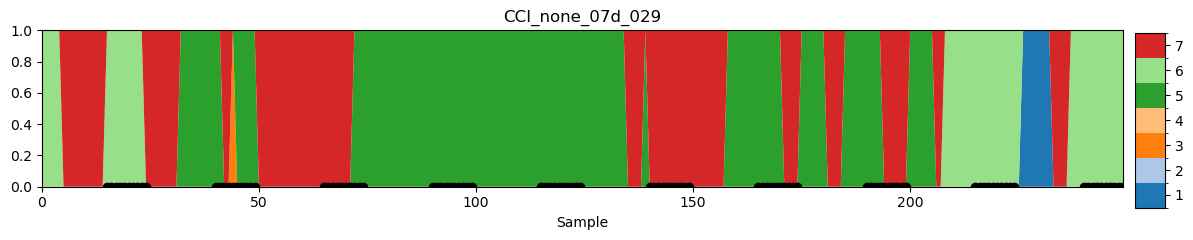

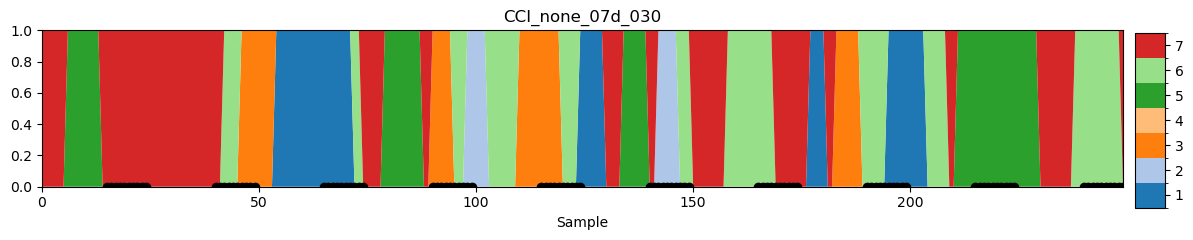

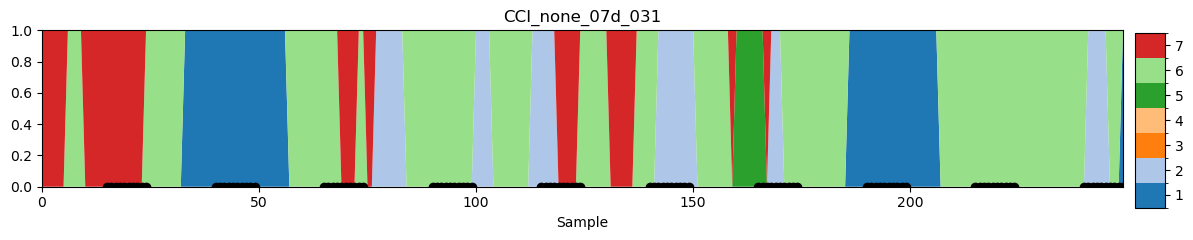

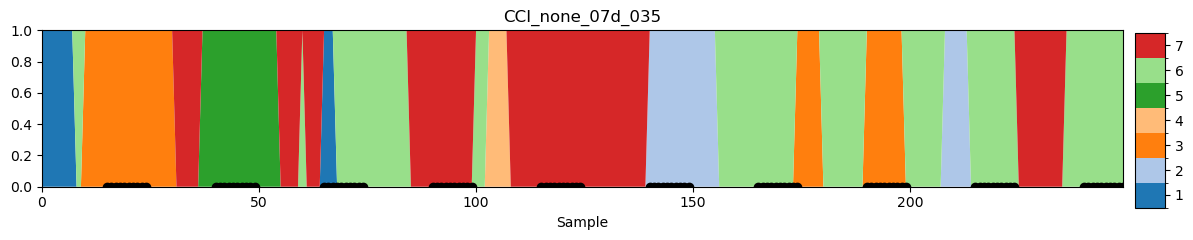

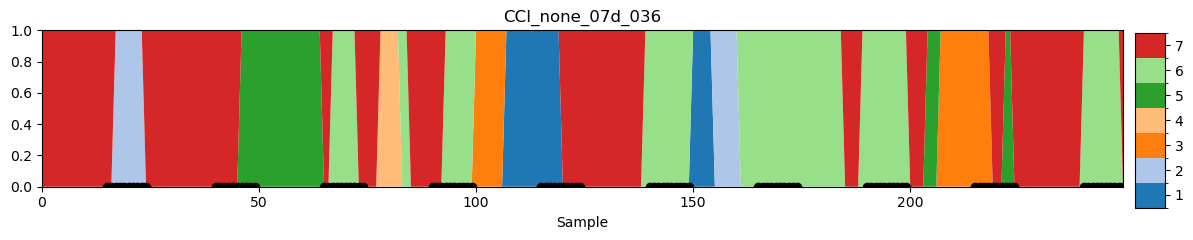

In [96]:
# CCI_none_07d
for subj in np.where(y == 'CCI_none_07d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'CIMT/LLstim' or experiment == 'CIMT/RLstim':
        add_stim_times(ax[0])

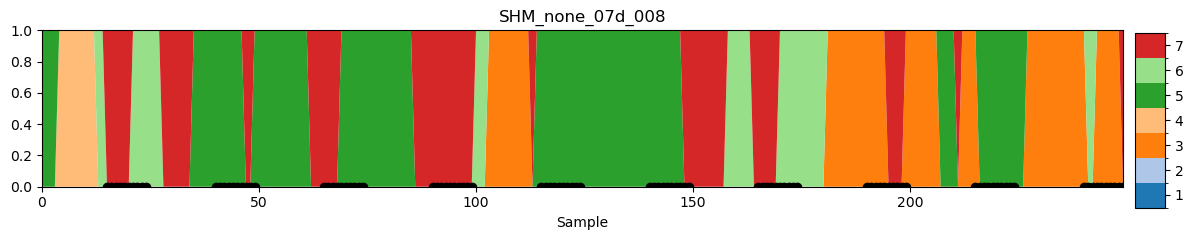

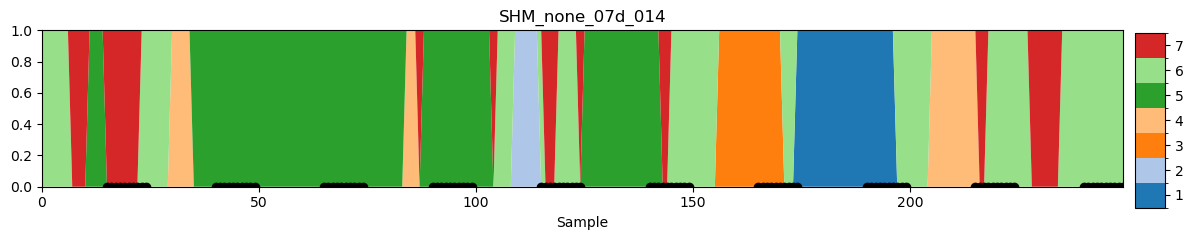

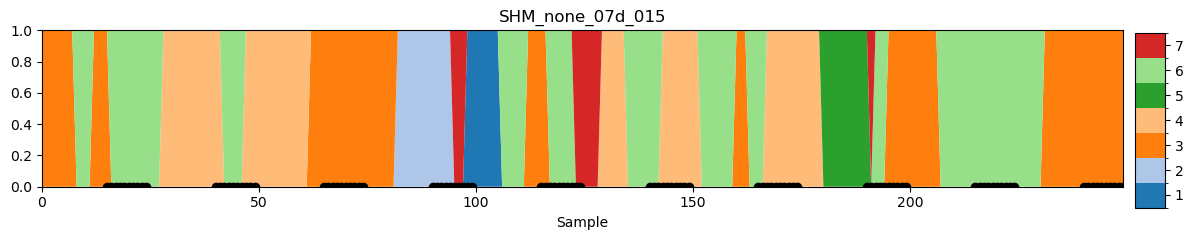

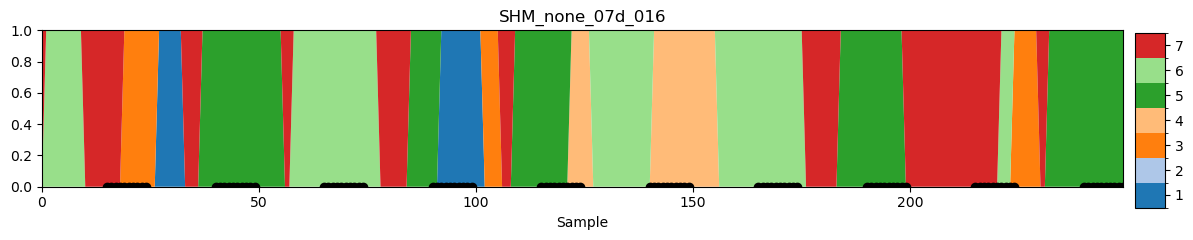

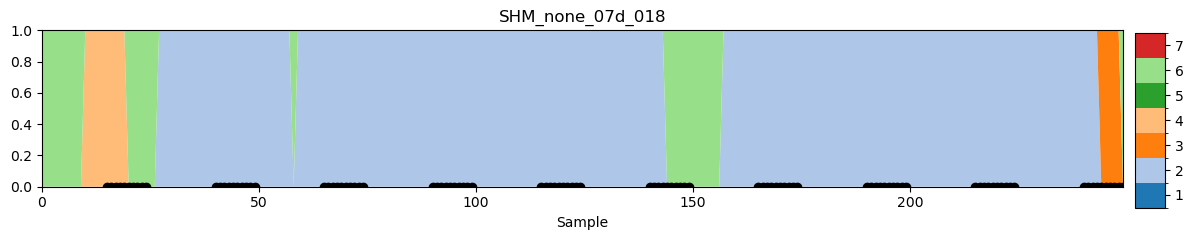

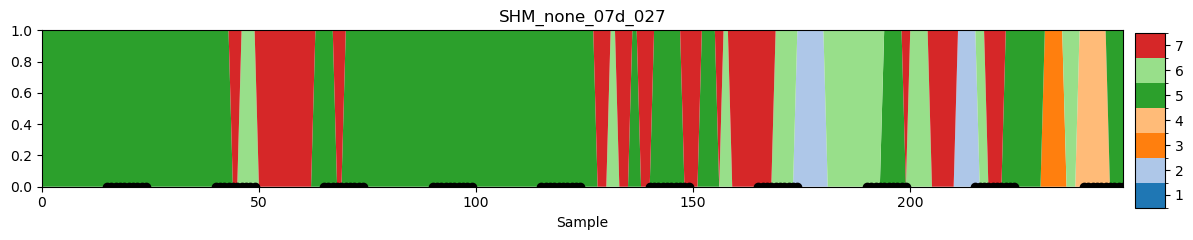

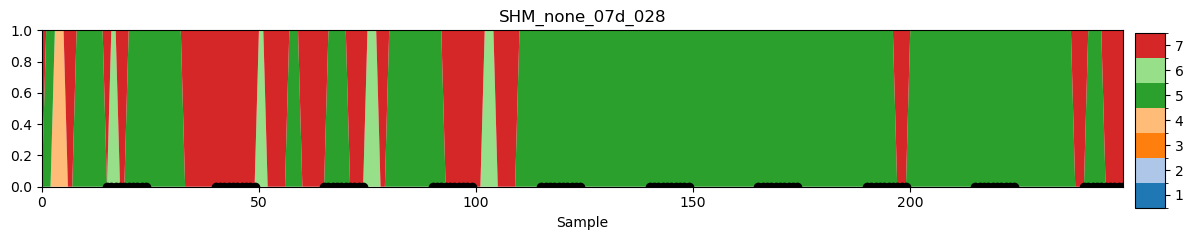

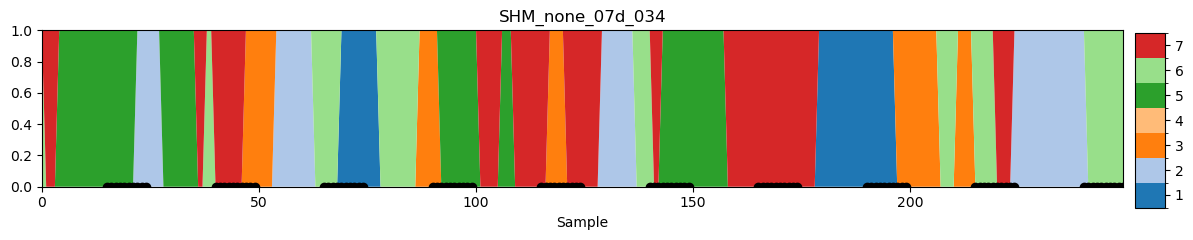

In [97]:
# SHM_none_07d
for subj in np.where(y == 'SHM_none_07d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'CIMT/LLstim' or experiment == 'CIMT/RLstim':
        add_stim_times(ax[0])

### 21d

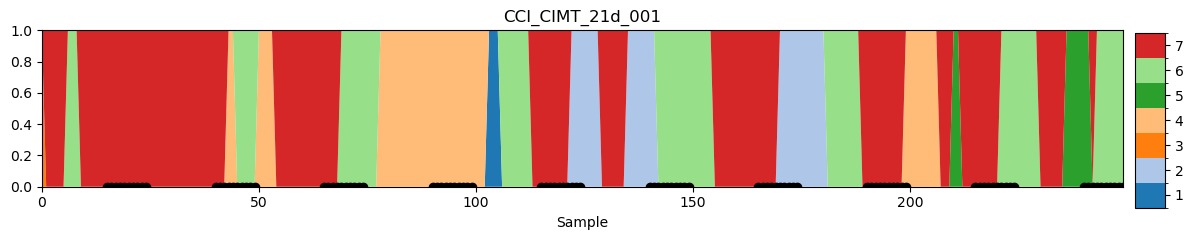

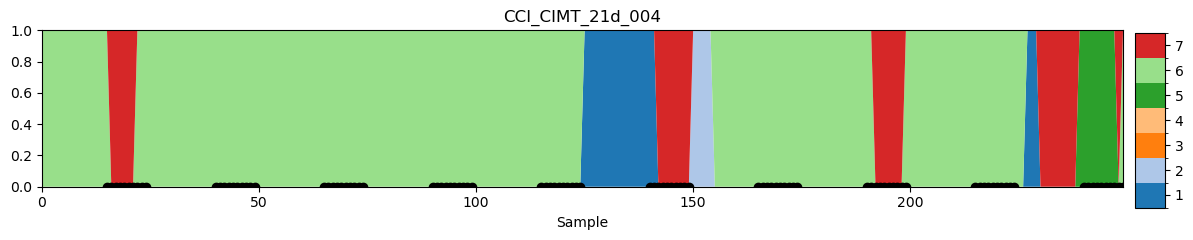

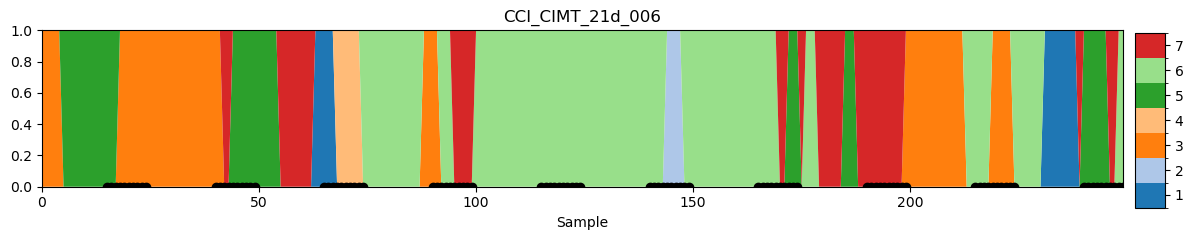

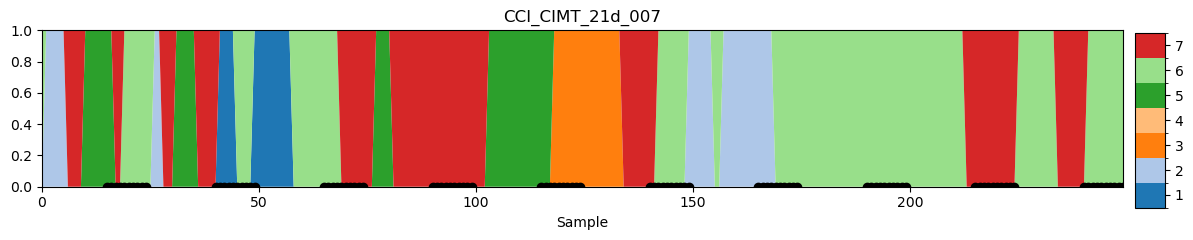

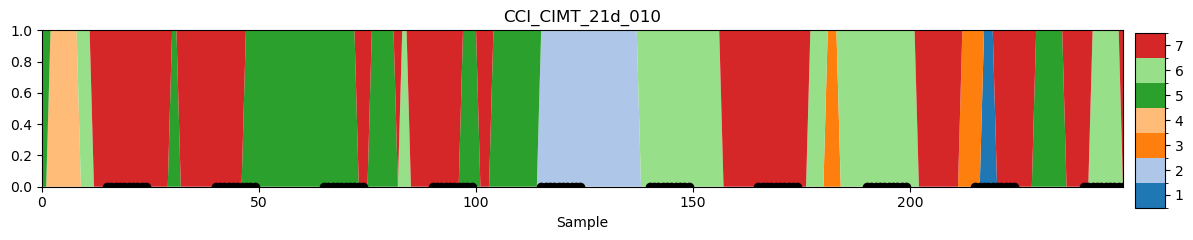

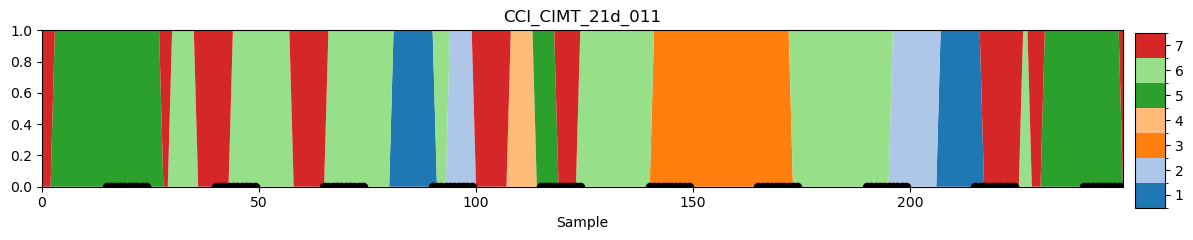

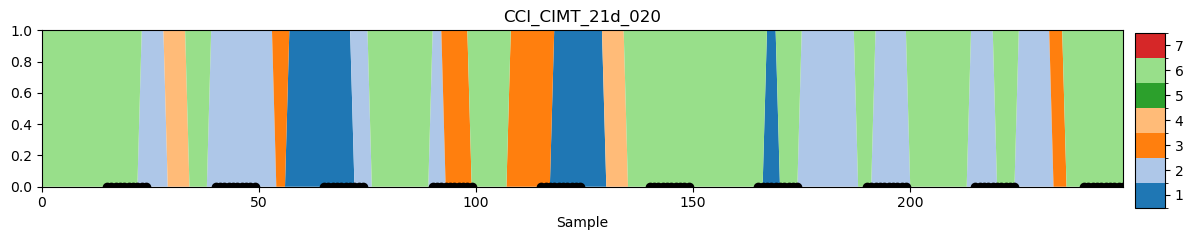

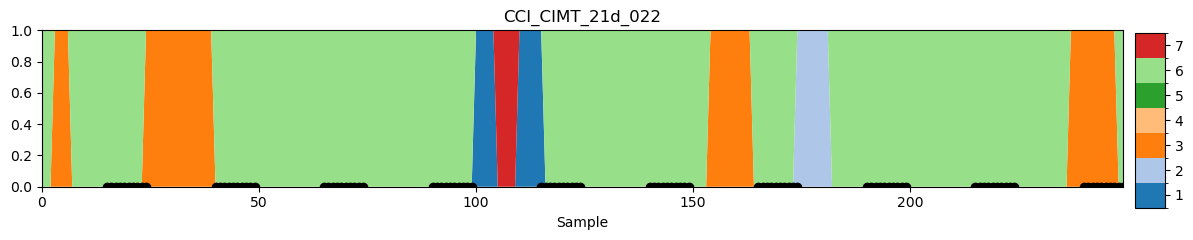

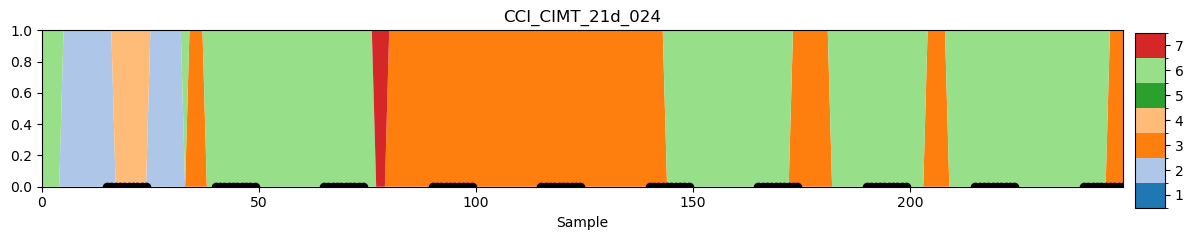

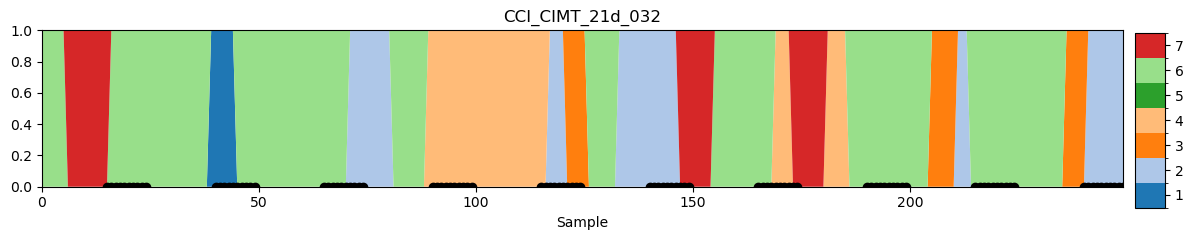

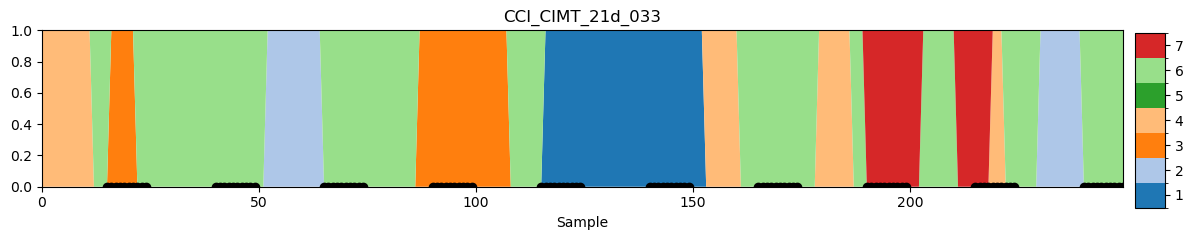

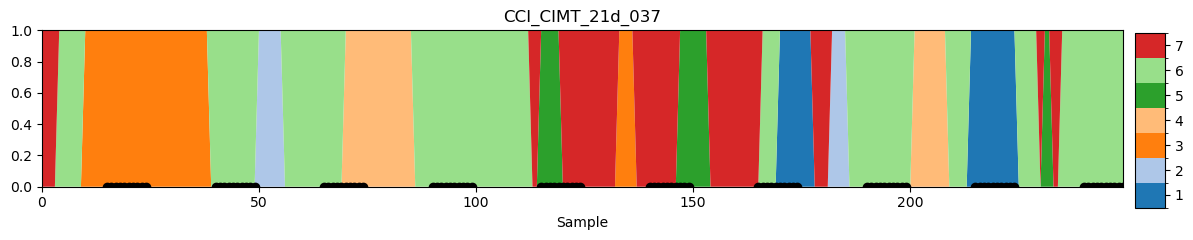

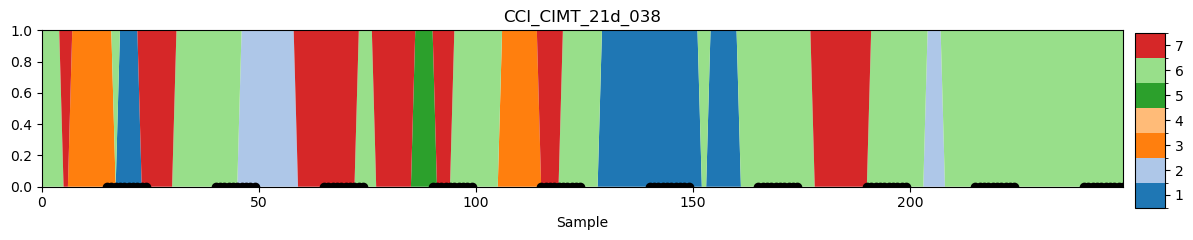

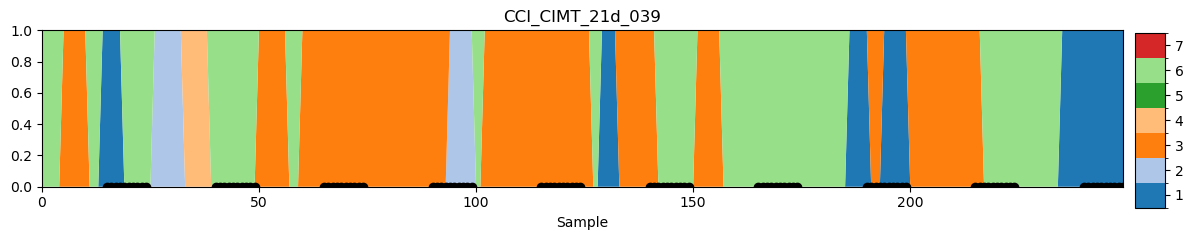

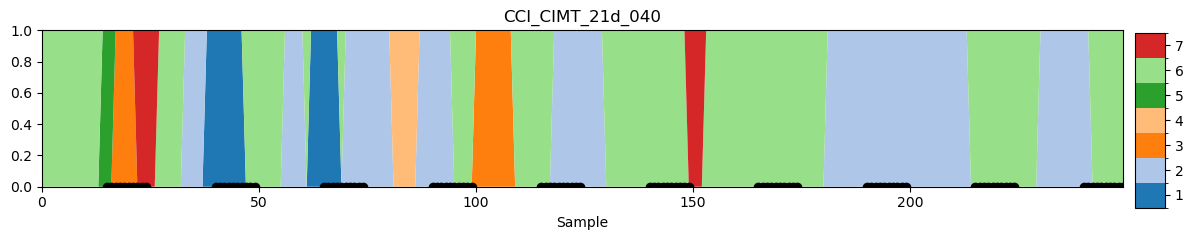

In [101]:
# CCI_CIMT_21d
for subj in np.where(y == 'CCI_CIMT_21d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'CIMT/LLstim' or experiment == 'CIMT/RLstim':
        add_stim_times(ax[0])

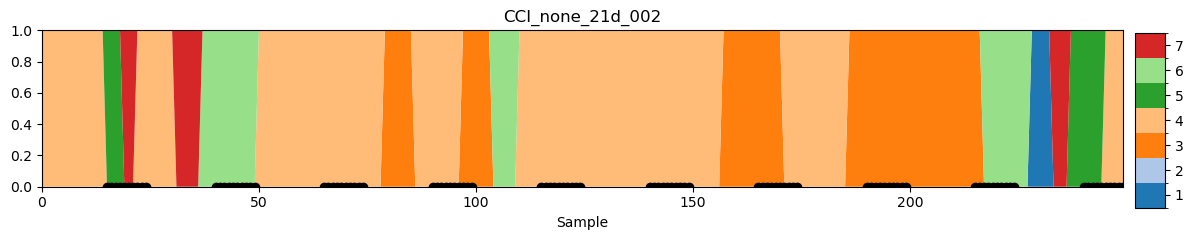

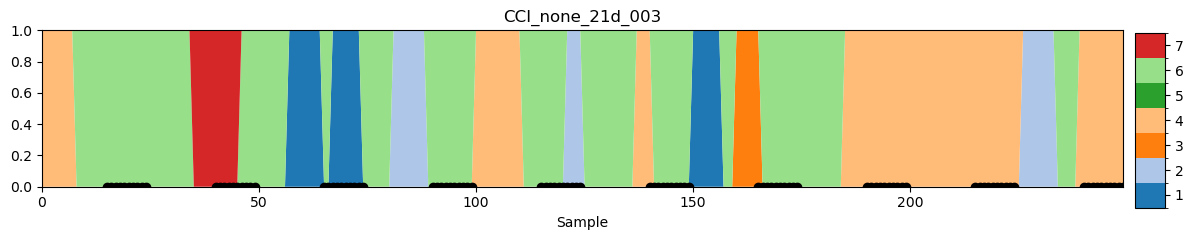

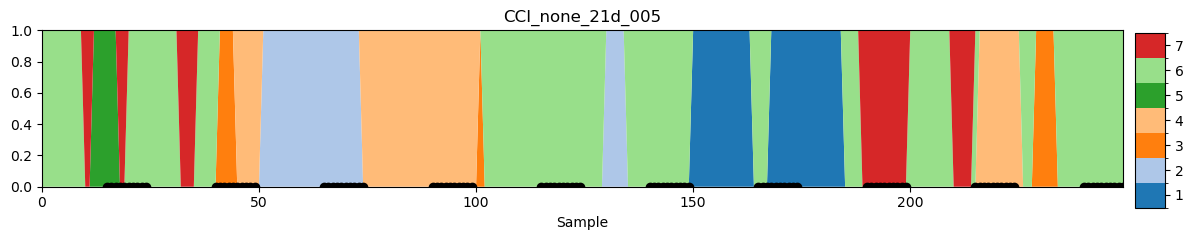

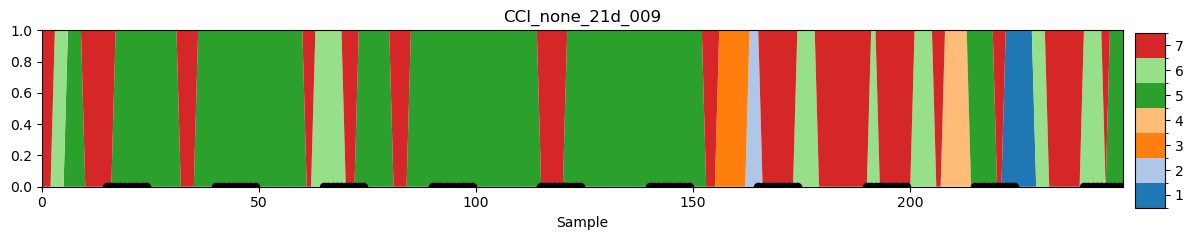

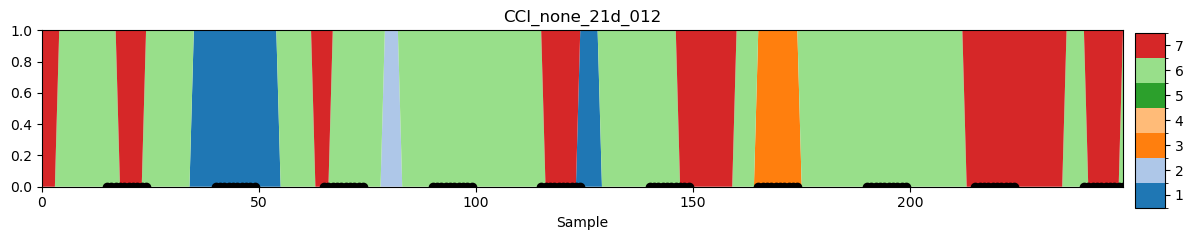

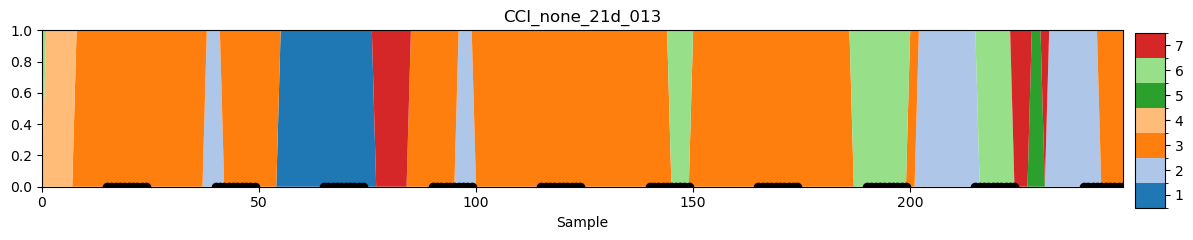

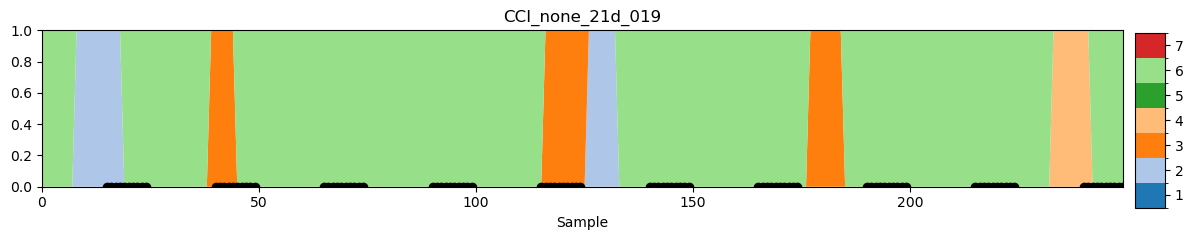

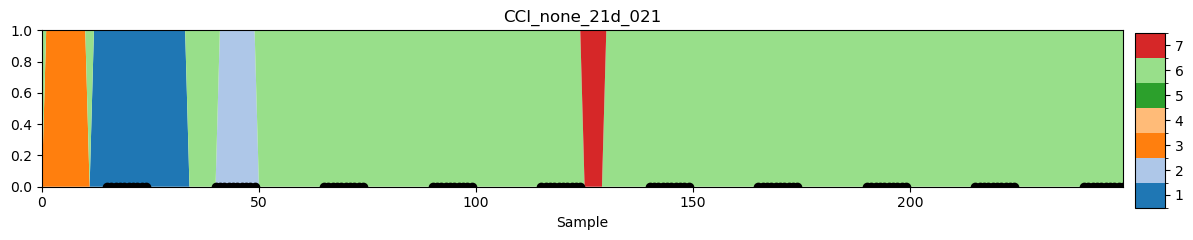

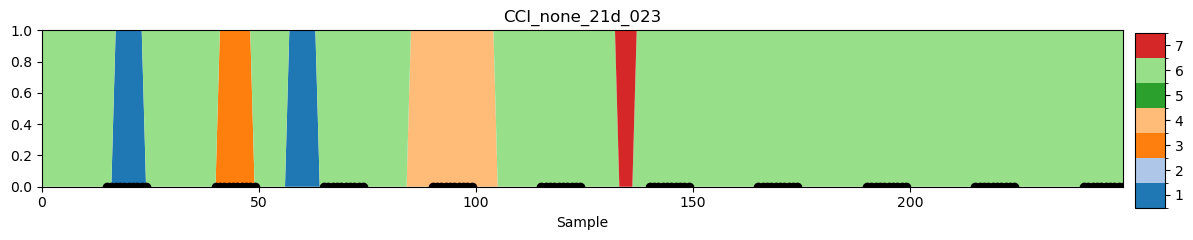

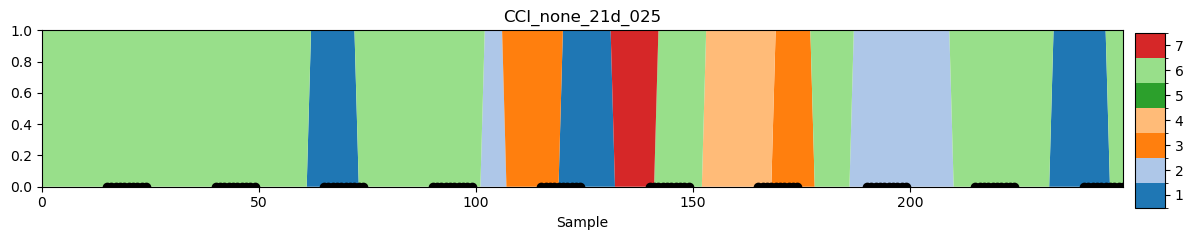

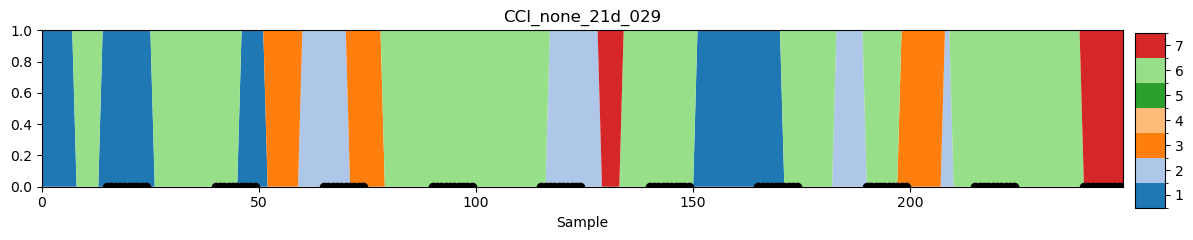

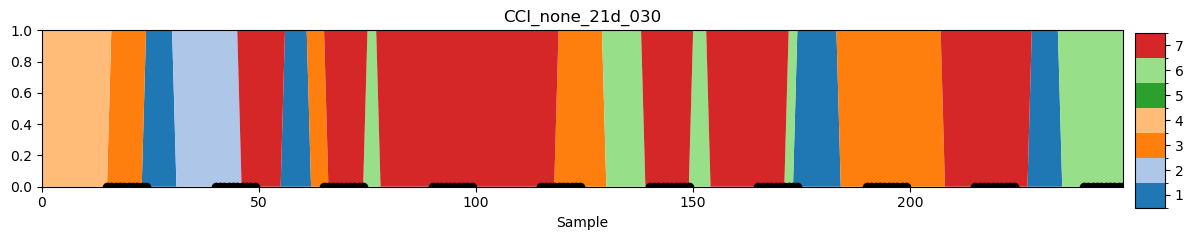

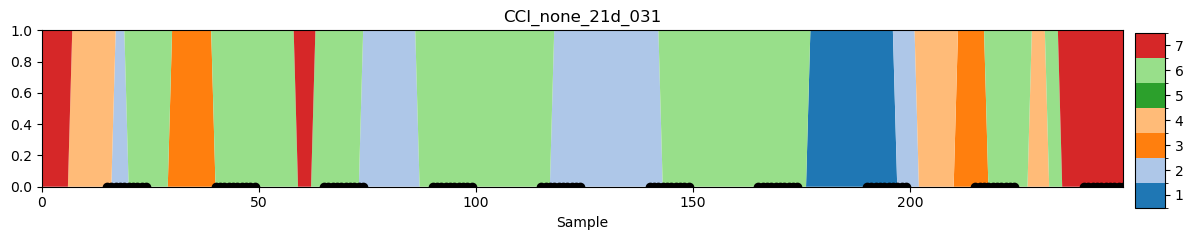

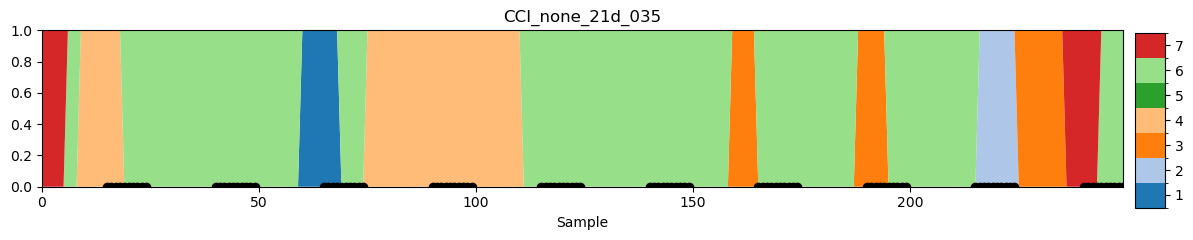

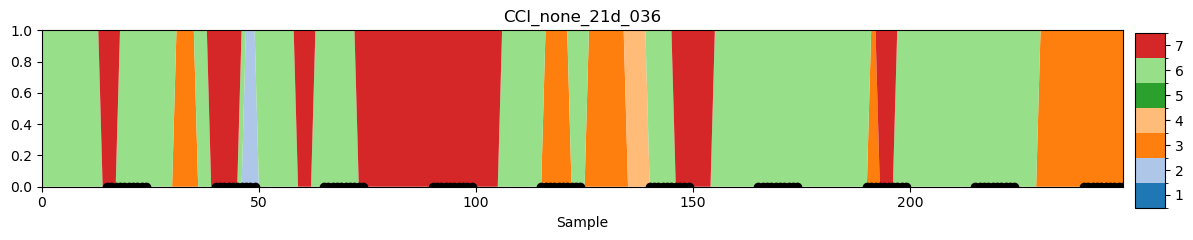

In [102]:
# CCI_none_21d
for subj in np.where(y == 'CCI_none_21d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'CIMT/LLstim' or experiment == 'CIMT/RLstim':
        add_stim_times(ax[0])

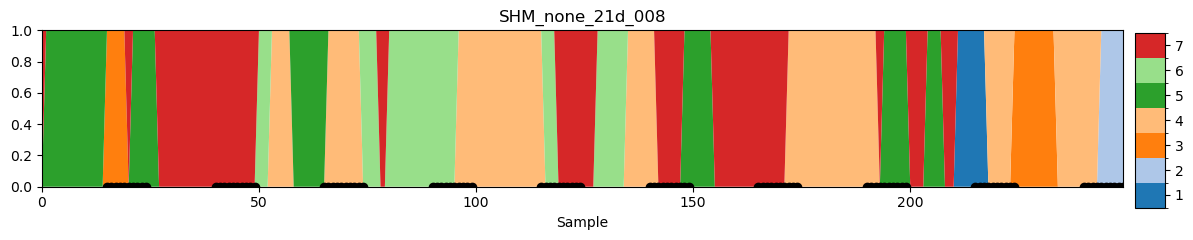

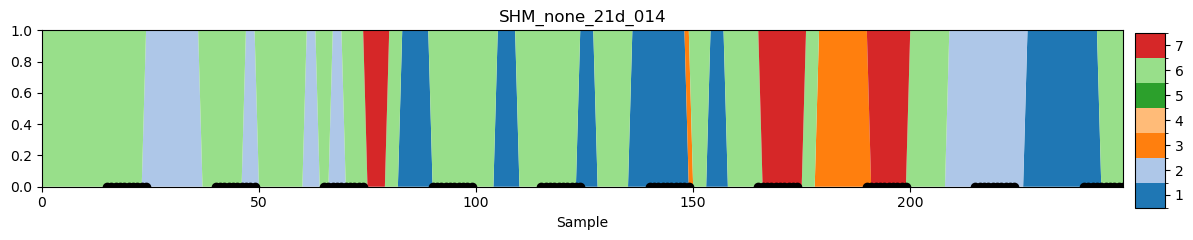

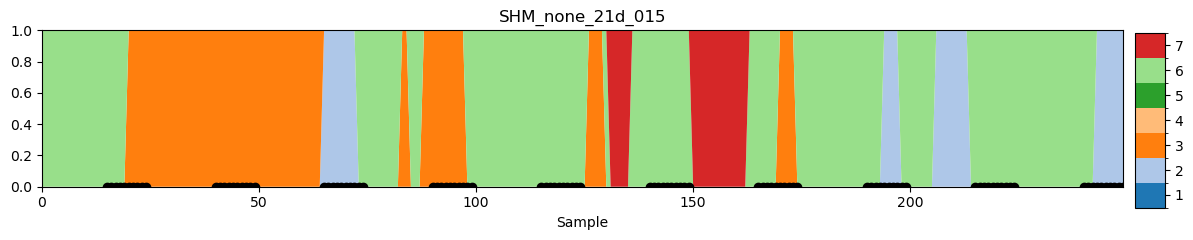

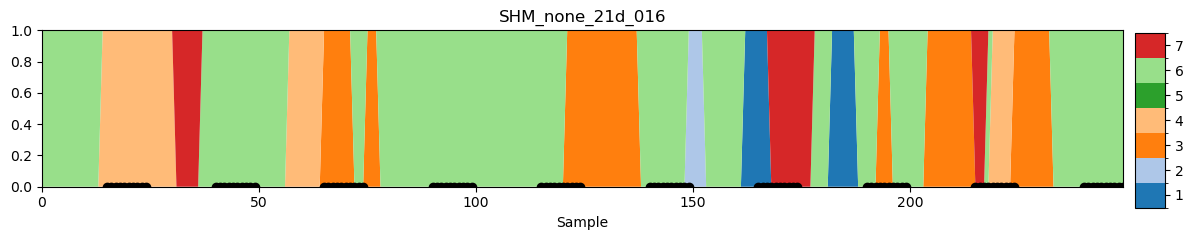

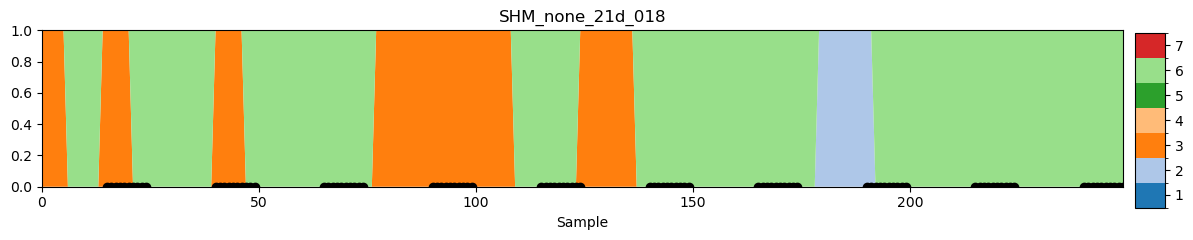

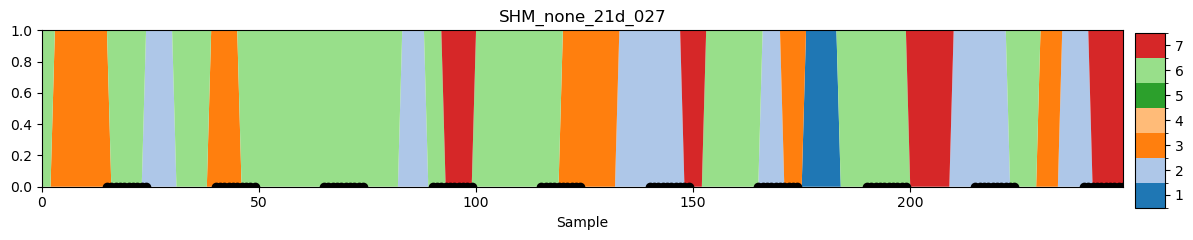

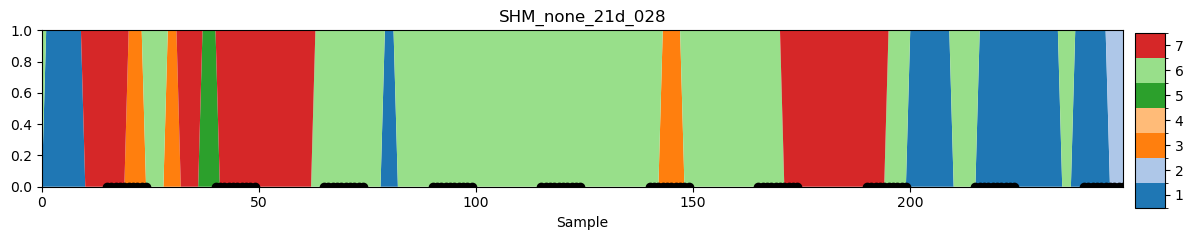

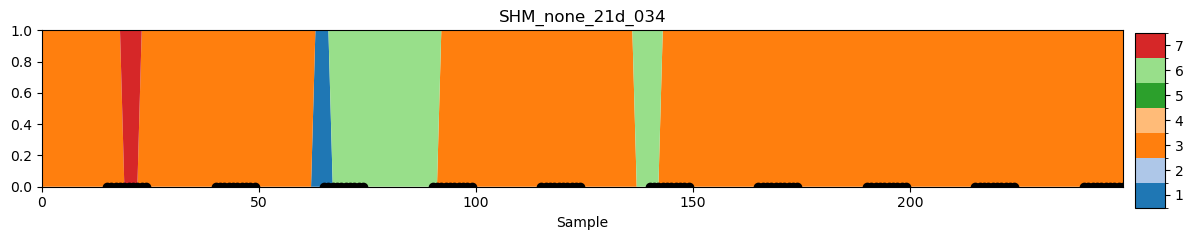

In [103]:
# SHM_none_21d
for subj in np.where(y == 'SHM_none_21d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'CIMT/LLstim' or experiment == 'CIMT/RLstim':
        add_stim_times(ax[0])

### 49d

In [ ]:
# CCI_CIMT_49d
for subj in np.where(y == 'CCI_CIMT_49d')[0]:
    fig, ax = plotting.plot_alpha(stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]))
    if experiment == 'CLLstim' or experiment == 'RLstim':
        add_stim_times(ax[0])